In [13]:
import cv2
import torch
import numpy as np
from ultralytics import YOLO

In [14]:
import sys
PROJECT_ROOT = r"D:\FYP\PlantGrowth"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
sys.path.insert(0, PROJECT_ROOT)

In [15]:
from models.stage_head import StageClassifier

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

stage_model = StageClassifier().to(DEVICE)
stage_model.load_state_dict(
    torch.load("../models/stage_classifier.pth", map_location=DEVICE)
)
stage_model.eval()

C:\Users\SRIRAM\AppData\Local\Temp\ipykernel_11436\66326366.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("../models/stage_classifier.pth", map_location=DEV

StageClassifier(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
        

In [16]:
detector = YOLO("../runs/detect/runs/laboro_fast_high_map50/weights/best.pt")

In [17]:

# Growth regressor
class GrowthRegressor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(2, 16),
            torch.nn.ReLU(),
            torch.nn.Linear(16, 8),
            torch.nn.ReLU(),
            torch.nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

growth_model = GrowthRegressor().to(DEVICE)
growth_model.load_state_dict(
    torch.load("../models/growth_regressor.pth", map_location=DEVICE)
)
growth_model.eval()

C:\Users\SRIRAM\AppData\Local\Temp\ipykernel_11436\1370695665.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("../models/growth_regressor.pth", map_location=

GrowthRegressor(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)

In [18]:
def hsv_ripeness(crop):
    hsv = cv2.cvtColor(crop, cv2.COLOR_RGB2HSV)
    h, s, _ = cv2.split(hsv)

    red = ((h < 10) | (h > 160)) & (s > 80)
    green = (h > 35) & (h < 85) & (s > 60)

    if np.sum(red) / h.size > 0.25:
        return 1
    elif np.sum(green) / h.size > 0.25:
        return 0.0
    else:
        return 0.5

In [33]:
img_path = r"D:\FYP\PlantGrowth\data\laboro_tomato\train\images\IMG_20191215_112848.jpg"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# ---- Stage prediction ----
stage_tensor = torch.tensor(
    img_rgb / 255.0, dtype=torch.float32
).permute(2, 0, 1).unsqueeze(0).to(DEVICE)

with torch.no_grad():
    stage_score = torch.softmax(stage_model(stage_tensor), dim=1)[0, 1].item()

In [34]:

# ---- Fruit detection ----
results = detector.predict(img_rgb, conf=0.4, device=0)[0]

ripeness_scores = []

for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    crop = img_rgb[y1:y2, x1:x2]

    if crop.size == 0:
        continue

    r = hsv_ripeness(crop)
    ripeness_scores.append(r)

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

# ---- Growth logic ----
if len(ripeness_scores) == 0:
    ripeness_score = 0.0
else:
    ripeness_score = float(np.mean(ripeness_scores))

X = torch.tensor(
    [[stage_score, ripeness_score]],
    dtype=torch.float32
).to(DEVICE)

with torch.no_grad():
    growth = growth_model(X).item()


0: 640x480 2 l_greens, 10.5ms
Speed: 11.0ms preprocess, 10.5ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)


In [35]:
import matplotlib.pyplot as plt

Growth Percentage (with fruit): 44.63%


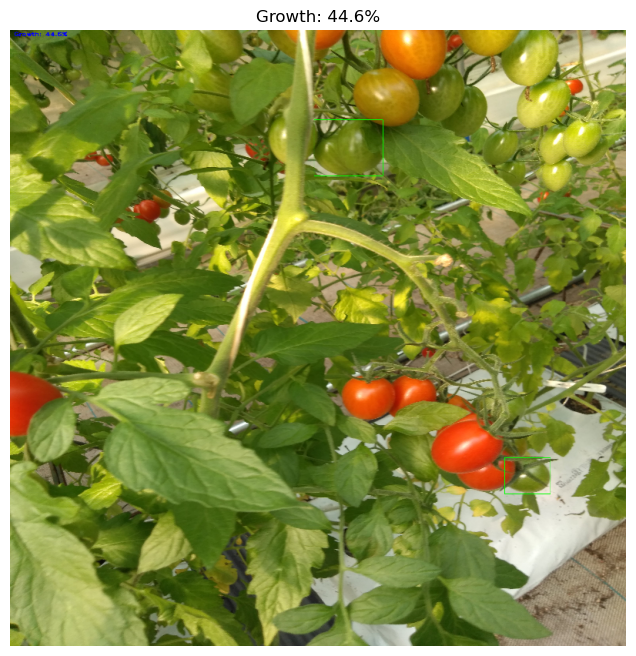

In [36]:
# ---- Display ----
if len(ripeness_scores) == 0:
    print(f"Growth Percentage (no fruit): {growth:.2f}%")
else:
    print(f"Growth Percentage (with fruit): {growth:.2f}%")
    cv2.putText(
        img,
        f"Growth: {growth:.1f}%",
        (20, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.2,
        (255, 0, 0),
        3
    )
    
    DISPLAY_W, DISPLAY_H = 800, 800
    img_show = cv2.resize(img, (DISPLAY_W, DISPLAY_H))
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img_show, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Growth: {growth:.1f}%")
    plt.show()